In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_excel('LiV2O4(H=100 Oe)#1.xls')
data1 = data
#data1

Estimar Weiss temperature

In [3]:
data1=data1.rename(columns={'emu/mol':'M_emu/mol'})
data1

,K,M_emu/mol
0,1.9989,1.187370
1,3.9984,1.113257
2,6.0038,1.097915
3,7.9998,1.096866
4,9.9980,1.099673
5,11.9990,1.102138
6,14.0260,1.102321
7,15.9980,1.100040
8,17.9930,1.095634
9,22.0010,1.081761


In [4]:
# Unit conversion
#calculating x, since x=M/H, using H=100 Oe
data1['x_emu/(mol.Oe)']=data1['M_emu/mol']/100
#converting to J/mol.T^2, since 1T=10000 Oe and 1J/T=10^3 emu
data1['x_J/(mol.T^2)']=data1['x_emu/(mol.Oe)']*10000*(1/1000)
#taking 1/x
data1['1/x_(mol.T^2)/J']=1/data1['x_J/(mol.T^2)']
data1

,K,M_emu/mol,x_emu/(mol.Oe),x_J/(mol.T^2),1/x_(mol.T^2)/J
0,1.9989,1.187370,0.011874,0.118737,8.421978
1,3.9984,1.113257,0.011133,0.111326,8.982650
2,6.0038,1.097915,0.010979,0.109792,9.108169
3,7.9998,1.096866,0.010969,0.109687,9.116880
4,9.9980,1.099673,0.010997,0.109967,9.093616
5,11.9990,1.102138,0.011021,0.110214,9.073276
6,14.0260,1.102321,0.011023,0.110232,9.071765
7,15.9980,1.100040,0.011000,0.110004,9.090581
8,17.9930,1.095634,0.010956,0.109563,9.127137
9,22.0010,1.081761,0.010818,0.108176,9.244188


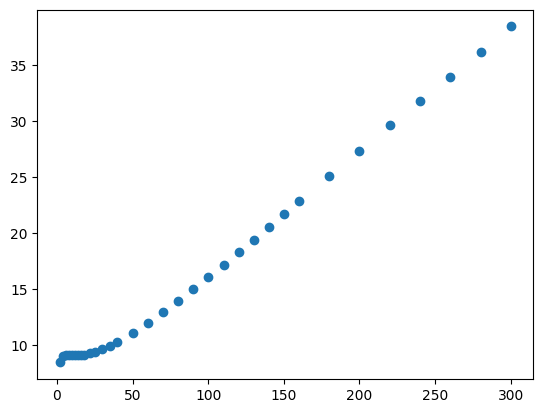

In [6]:
plt.scatter(data1['K'],data1['1/x_(mol.T^2)/J'])

In [75]:
#taking a temperature range from 200 to 300
data2 = data1[data1['K'] >= 50]
data2

,K,M_emu/mol,x_emu/(mol.Oe),x_J/(mol.T^2),1/x_(mol.T^2)/J
14,50.009,0.904033,0.009040,0.090403,11.061548
15,60.052,0.837053,0.008371,0.083705,11.946668
16,70.077,0.775031,0.007750,0.077503,12.902711
17,80.111,0.719014,0.007190,0.071901,13.907937
18,90.152,0.668688,0.006687,0.066869,14.954662
19,100.190,0.623633,0.006236,0.062363,16.035074
20,110.220,0.583535,0.005835,0.058353,17.136945
21,120.250,0.547685,0.005477,0.054768,18.258679
22,130.280,0.515611,0.005156,0.051561,19.394453
23,140.290,0.486869,0.004869,0.048687,20.539425


In [76]:
#fitting using linalg
A = np.vstack([data2['K'], np.ones(len(data2['K']))]).T
m, b = np.linalg.lstsq(A, data2['1/x_(mol.T^2)/J'])[0]
m, b

C:\Users\shann\AppData\Local\Temp\ipykernel_33764\1108139443.py:3: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m, b = np.linalg.lstsq(A, data2['1/x_(mol.T^2)/J'])[0]


(0.11095140560748377, 5.081950860773891)

In [77]:
print(f"m = {m} \nb = {b}")

m = 0.11095140560748377 
b = 5.081950860773891


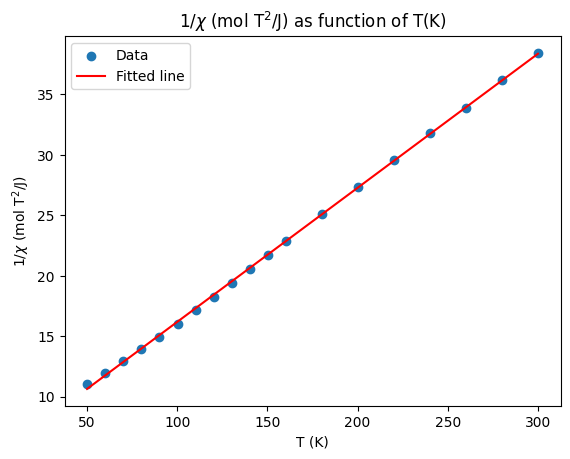

In [78]:
plt.scatter(data2['K'], data2['1/x_(mol.T^2)/J'], label='Data')
plt.plot(data2['K'], m*data2['K']+b, 'r', label='Fitted line')
plt.title(r'1/$\chi$ (mol T$^2$/J) as function of T(K)')
plt.ylabel(r'1/$\chi$ (mol T$^2$/J)')
plt.xlabel('T (K)')
plt.legend()

In [79]:
#calculando C y Theta
# since m = 1/C, then
C = 1/m
# since b = -Theta/C, then
Theta = -b*C
print(f"C = {C} (J*K/mol*T^2) \n\u0398 = {Theta} (K)")

C = 9.012954766321132 (J*K/mol*T^2) 
Θ = -45.80339323282182 (K)


In [80]:
# C esta en [m^3.K/mol]
C_V = C/2
print(f"C_V = {C_V} (J*K/T^2 mol_V)")

C_V = 4.506477383160566 (J*K/T^2 mol_V)


In [81]:
#calculating mu in SI
# using C=N*mu^2/3k
# setting the constant values
k = 1.380649e-23 # [J/K]
N_A = 6.02214076e23 # [mol^-1] de V
mu = np.sqrt((3*k*C_V)/(N_A)) # [] 
mu # [J/T]
print(f"\u03BC = {mu} (J/T)")

μ = 1.7605380484434756e-23 (J/T)


In [82]:
#calculating mu_eff
mu_B = 9.2740100657e-24# [J/T]
mu_eff = mu/mu_B
mu_eff
print(f'\u03BC_eff = {mu_eff}')

μ_eff = 1.8983568445270935
